In [1]:
from sklearn.cluster import KMeans
import pandas as pd 
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import numpy as np 
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv(r'D:\python assignments\Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
x = df.drop('Spending Score (1-100)', axis=1)
y = df['Spending Score (1-100)']

In [4]:
lab = LabelEncoder()
df['Gender'] = lab.fit_transform(df['Gender'])

In [5]:
model = KMeans(n_clusters=5)
res = model.fit_predict(df)

In [6]:
df['Cluster'] = res

In [7]:
cluster_profiles = df.groupby('Cluster')

In [8]:
wcss = []
for k in range(1,11): 
    model = KMeans(n_clusters=k)
    model.fit_predict(df)
    wcss.append(model.inertia_)
    print(wcss)

[975906.2150000001]
[975906.2150000001, 387450.67866786674]
[975906.2150000001, 387450.67866786674, 272394.44471401465]
[975906.2150000001, 387450.67866786674, 272394.44471401465, 195497.43974622365]
[975906.2150000001, 387450.67866786674, 272394.44471401465, 195497.43974622365, 157631.78748035248]
[975906.2150000001, 387450.67866786674, 272394.44471401465, 195497.43974622365, 157631.78748035248, 145091.37434457603]
[975906.2150000001, 387450.67866786674, 272394.44471401465, 195497.43974622365, 157631.78748035248, 145091.37434457603, 106153.34372268095]
[975906.2150000001, 387450.67866786674, 272394.44471401465, 195497.43974622365, 157631.78748035248, 145091.37434457603, 106153.34372268095, 86173.8998650504]
[975906.2150000001, 387450.67866786674, 272394.44471401465, 195497.43974622365, 157631.78748035248, 145091.37434457603, 106153.34372268095, 86173.8998650504, 90063.07101476955]
[975906.2150000001, 387450.67866786674, 272394.44471401465, 195497.43974622365, 157631.78748035248, 14509

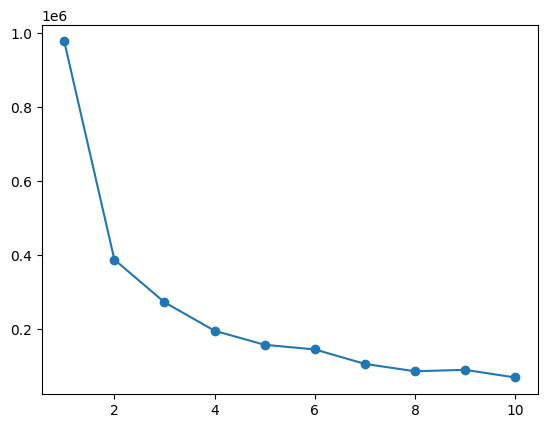

In [9]:
plt.plot(range(1,11), wcss, marker='o')
plt.show()